#**Data fetching**



*   Used the yfinance library to fetch historical MSFT stock data

*   Collected data including Open, High, Low, Close prices, Volume, Dividends, and Stock Splits

*   Data spans from 1986 to 2025 (simulated future data)



In [ ]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import yfinance as yf

In [ ]:
msft=yf.Ticker("MSFT")

In [ ]:
msft=msft.history(period="max")

In [ ]:
msft

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1986-03-13 00:00:00-05:00,0.054376,0.062373,0.054376,0.059707,1031788800,0.0,0.0
1986-03-14 00:00:00-05:00,0.059707,0.062906,0.059707,0.061839,308160000,0.0,0.0
1986-03-17 00:00:00-05:00,0.061839,0.063439,0.061839,0.062906,133171200,0.0,0.0
1986-03-18 00:00:00-05:00,0.062906,0.063439,0.060773,0.061306,67766400,0.0,0.0
1986-03-19 00:00:00-05:00,0.061306,0.061839,0.059707,0.060240,47894400,0.0,0.0
...,...,...,...,...,...,...,...
2025-04-04 00:00:00-04:00,364.130005,374.589996,359.480011,359.839996,49209900,0.0,0.0
2025-04-07 00:00:00-04:00,350.880005,371.000000,344.790009,357.859985,50425000,0.0,0.0
2025-04-08 00:00:00-04:00,368.260010,373.649994,350.250000,354.559998,35868900,0.0,0.0


<AxesSubplot: xlabel='Date'>

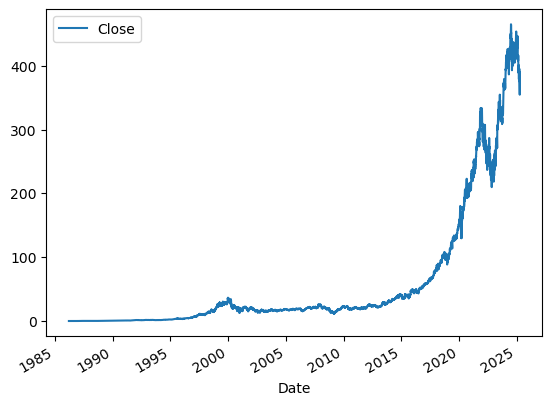

In [ ]:
msft.plot.line(y="Close", use_index=True)

#**Data Preprocessing**



*  Applied RobustScaler to scale features and handle outliers.

*  Created binary target variable:

  *  1 if the next day's close > current day's close

  *  0 otherwise

*  Used previous day’s values of predictors for prediction (shift(1)).

*  Selected predictors: ["Close", "High", "Low", "Open", "Volume"].




In [ ]:
from sklearn.preprocessing import RobustScaler

scaler=RobustScaler()

msft_scaled=scaler.fit_transform(msft)

In [ ]:
msft_scaled

array([[-5.20406935e-01, -5.22263384e-01, -5.20155503e-01, ...,
         2.52238772e+01,  0.00000000e+00,  0.00000000e+00],
       [-5.20262763e-01, -5.22249064e-01, -5.20009725e-01, ...,
         6.64671421e+00,  0.00000000e+00,  0.00000000e+00],
       [-5.20205094e-01, -5.22234743e-01, -5.19951414e-01, ...,
         2.15436197e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 9.43805196e+00,  9.51424664e+00,  9.05666559e+00, ...,
        -3.43604791e-01,  0.00000000e+00,  0.00000000e+00],
       [ 9.03993603e+00,  1.00402679e+01,  9.13460488e+00, ...,
         2.21140566e-02,  0.00000000e+00,  0.00000000e+00],
       [ 9.81966944e+00,  9.78961504e+00,  9.85328561e+00, ...,
        -1.13791868e+00,  0.00000000e+00,  0.00000000e+00]])

In [ ]:
import pandas as pd
msft_scaled=pd.DataFrame(msft_scaled, columns=msft.columns,index=msft.index)

In [ ]:
msft_scaled

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1986-03-13 00:00:00-05:00,-0.520407,-0.522263,-0.520156,-0.520309,25.223877,0.0,0.0
1986-03-14 00:00:00-05:00,-0.520263,-0.522249,-0.520010,-0.520251,6.646714,0.0,0.0
1986-03-17 00:00:00-05:00,-0.520205,-0.522235,-0.519951,-0.520222,2.154362,0.0,0.0
1986-03-18 00:00:00-05:00,-0.520176,-0.522235,-0.519981,-0.520266,0.475275,0.0,0.0
1986-03-19 00:00:00-05:00,-0.520220,-0.522278,-0.520010,-0.520295,-0.034883,0.0,0.0
...,...,...,...,...,...,...,...
2025-04-04 00:00:00-04:00,9.326352,9.539500,9.309079,9.212156,-0.001112,0.0,0.0
2025-04-07 00:00:00-04:00,8.967994,9.443054,8.907351,9.158594,0.030083,0.0,0.0
2025-04-08 00:00:00-04:00,9.438052,9.514247,9.056666,9.069326,-0.343605,0.0,0.0


In [ ]:
data=msft_scaled["Close"]
data=data.rename("Actual_Close")


In [ ]:
data=data.to_frame()


In [ ]:
data["Target"]=data["Actual_Close"].rolling(2).apply(lambda x:x.iloc[1]>x.iloc[0])

In [ ]:
data

,Actual_Close,Target
Date,,
1986-03-13 00:00:00-05:00,-0.520309,NaN
1986-03-14 00:00:00-05:00,-0.520251,1.0
1986-03-17 00:00:00-05:00,-0.520222,1.0
1986-03-18 00:00:00-05:00,-0.520266,0.0
1986-03-19 00:00:00-05:00,-0.520295,0.0
...,...,...
2025-04-04 00:00:00-04:00,9.212156,0.0
2025-04-07 00:00:00-04:00,9.158594,0.0
2025-04-08 00:00:00-04:00,9.069326,0.0


In [ ]:
msft_prev=msft_scaled.copy()

In [ ]:
msft_prev=msft_prev.shift(1)

In [ ]:
msft_prev

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1986-03-13 00:00:00-05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1986-03-14 00:00:00-05:00,-0.520407,-0.522263,-0.520156,-0.520309,25.223877,0.0,0.0
1986-03-17 00:00:00-05:00,-0.520263,-0.522249,-0.520010,-0.520251,6.646714,0.0,0.0
1986-03-18 00:00:00-05:00,-0.520205,-0.522235,-0.519951,-0.520222,2.154362,0.0,0.0
1986-03-19 00:00:00-05:00,-0.520176,-0.522235,-0.519981,-0.520266,0.475275,0.0,0.0
...,...,...,...,...,...,...,...
2025-04-04 00:00:00-04:00,9.614662,9.617141,9.578995,9.571124,-0.489189,0.0,0.0
2025-04-07 00:00:00-04:00,9.326352,9.539500,9.309079,9.212156,-0.001112,0.0,0.0
2025-04-08 00:00:00-04:00,8.967994,9.443054,8.907351,9.158594,0.030083,0.0,0.0


In [ ]:
predictors=["Close","High","Low","Open","Volume"]

In [ ]:
data=data.join(msft_prev[predictors])

In [ ]:
data=data.iloc[1:]

In [ ]:
data

,Actual_Close,Target,Close,High,Low,Open,Volume
Date,,,,,,,
1986-03-14 00:00:00-05:00,-0.520251,1.0,-0.520309,-0.522263,-0.520156,-0.520407,25.223877
1986-03-17 00:00:00-05:00,-0.520222,1.0,-0.520251,-0.522249,-0.520010,-0.520263,6.646714
1986-03-18 00:00:00-05:00,-0.520266,0.0,-0.520222,-0.522235,-0.519951,-0.520205,2.154362
1986-03-19 00:00:00-05:00,-0.520295,0.0,-0.520266,-0.522235,-0.519981,-0.520176,0.475275
1986-03-20 00:00:00-05:00,-0.520338,0.0,-0.520295,-0.522278,-0.520010,-0.520220,-0.034883
...,...,...,...,...,...,...,...
2025-04-04 00:00:00-04:00,9.212156,0.0,9.571124,9.617141,9.578995,9.614662,-0.489189
2025-04-07 00:00:00-04:00,9.158594,0.0,9.212156,9.539500,9.309079,9.326352,-0.001112
2025-04-08 00:00:00-04:00,9.069326,0.0,9.158594,9.443054,8.907351,8.967994,0.030083


#**Training ML Models**

**Random Forest**

*  Parameters: n_estimators=100, min_samples_split=200

*  Trained on full dataset excluding last 100 rows (used as test set)

*  Evaluated with precision_score

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model=RandomForestClassifier(n_estimators=100,min_samples_split=200,random_state=1)
train=data.iloc[:-100]
test=data.iloc[-100:]
model.fit(train[predictors],train["Target"])

RandomForestClassifier(min_samples_split=200, random_state=1)

In [ ]:
from sklearn.metrics import precision_score

preds=model.predict(test[predictors])
preds

array([0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 1.,
       0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1.])

In [ ]:
import pandas as pd
preds=pd.Series(preds, index=test.index)

In [ ]:
preds

Date
2024-11-14 00:00:00-05:00    0.0
2024-11-15 00:00:00-05:00    0.0
2024-11-18 00:00:00-05:00    1.0
2024-11-19 00:00:00-05:00    1.0
2024-11-20 00:00:00-05:00    1.0
                            ... 
2025-04-04 00:00:00-04:00    1.0
2025-04-07 00:00:00-04:00    1.0
2025-04-08 00:00:00-04:00    1.0
2025-04-09 00:00:00-04:00    0.0
2025-04-10 00:00:00-04:00    1.0
Length: 100, dtype: float64

In [ ]:
precision_score(test["Target"],preds)

0.4838709677419355

In [ ]:
combined= pd.concat({"Target":test["Target"],"Predictions":preds},axis=1)

In [ ]:
combined

,Target,Predictions
Date,,
2024-11-14 00:00:00-05:00,1.0,0.0
2024-11-15 00:00:00-05:00,0.0,0.0
2024-11-18 00:00:00-05:00,1.0,1.0
2024-11-19 00:00:00-05:00,1.0,1.0
2024-11-20 00:00:00-05:00,0.0,1.0
...,...,...
2025-04-04 00:00:00-04:00,0.0,1.0
2025-04-07 00:00:00-04:00,0.0,1.0
2025-04-08 00:00:00-04:00,0.0,1.0


<AxesSubplot: xlabel='Date'>

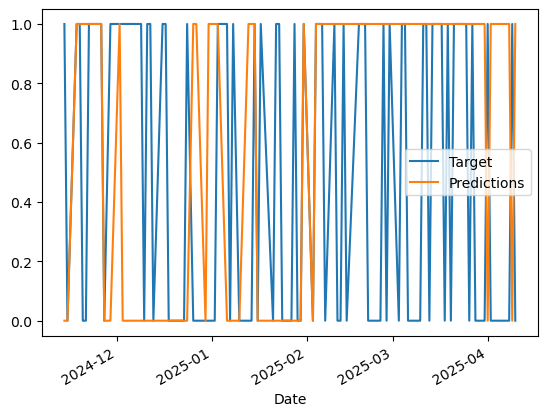

In [ ]:
combined.plot() #for random forest classifier

**Logistic Regression**

*  Trained using sklearn.linear_model.LogisticRegression

*  Simpler model to compare against more complex ones

In [ ]:
from sklearn.linear_model import LogisticRegression
model1=LogisticRegression()
model1.fit(train[predictors],train["Target"])

LogisticRegression()

In [ ]:
preds1=model1.predict(test[predictors])
preds1

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.])

In [ ]:
preds1=pd.Series(preds1, index=test.index)
preds1

Date
2024-11-14 00:00:00-05:00    1.0
2024-11-15 00:00:00-05:00    1.0
2024-11-18 00:00:00-05:00    1.0
2024-11-19 00:00:00-05:00    1.0
2024-11-20 00:00:00-05:00    1.0
                            ... 
2025-04-04 00:00:00-04:00    1.0
2025-04-07 00:00:00-04:00    1.0
2025-04-08 00:00:00-04:00    1.0
2025-04-09 00:00:00-04:00    1.0
2025-04-10 00:00:00-04:00    0.0
Length: 100, dtype: float64

In [ ]:
precision_score(test["Target"],preds1)

0.5104166666666666

In [ ]:
combined_LR= pd.concat({"Target":test["Target"],"Predictions":preds1},axis=1)

<AxesSubplot: xlabel='Date'>

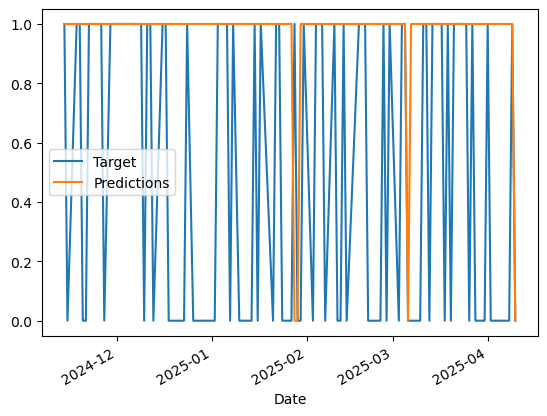

In [ ]:
combined_LR.plot() #for logistic regression

#**ANN**

*  Built using Keras + TensorFlow

*  Network architecture:

  *  Dense layers: 128 → 64 → 32 → 1 (sigmoid)

  *  Activation: LeakyReLU with Layer Normalization

  *  Loss: Binary Crossentropy

  *  Optimizer: Adam (lr=0.001)

  *  Metrics: Precision

In [ ]:
!pip install keras

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LayerNormalization, LeakyReLU, InputLayer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall


In [ ]:
ann_model = Sequential([
    Dense(128,input_dim=len(predictors)),
    LayerNormalization(),
    LeakyReLU(negative_slope=0.1),

    Dense(64),
    LayerNormalization(),
    LeakyReLU(negative_slope=0.1),

    Dense(32),
    LayerNormalization(),
    LeakyReLU(negative_slope=0.1),

    Dense(1, activation='sigmoid')
])


optimizer = Adam(
    learning_rate=0.001
)


ann_model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=["Precision"]
)

history = ann_model.fit(
    train[predictors],
    train["Target"],
    epochs=100,
    verbose=1
)




Epoch 1/100


/home/prashant/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


305/305 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - Precision: 0.5015 - loss: 0.7105
Epoch 2/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Precision: 0.5153 - loss: 0.6954
Epoch 3/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Precision: 0.5192 - loss: 0.6946
Epoch 4/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Precision: 0.5155 - loss: 0.6934
Epoch 5/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Precision: 0.5101 - loss: 0.6949
Epoch 6/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Precision: 0.5175 - loss: 0.6933
Epoch 7/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Precision: 0.5228 - loss: 0.6922
Epoch 8/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Precision: 0.5248 - loss: 0.6926
Epoch 9/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Precision: 0.5256 - loss: 0.6926
Epoch 10/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Precision: 0.5256 - loss: 0.6924
Epoch 11/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Precision: 0.4999 - loss: 0.6928
Epoch 12/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
test_probabilities = ann_model.predict(test[predictors])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [ ]:
test_predictions = (test_probabilities > 0.5).astype(int)

In [ ]:
test_precision = ann_model.evaluate(test[predictors], test["Target"], verbose=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Precision: 0.5208 - loss: 0.6930  


#**Backtesting**

*  To simulate real-world performance, walk-forward validation was used:

*  Split data into overlapping train-test splits using step and start values.

*  For each window:

*  Train on current slice

*  Predict on next slice

*  Store results for evaluation

**Backtesting Implementations:**
*  backtest() for Random Forest and Logistic Regression

*  backtestANN() for ANN model

In [ ]:
def backtest(data, model, predictors, start=1000, step=500):
  predictions=[]
  for i in range(start, data.shape[0],step):
    train=data.iloc[0:i].copy()
    test=data.iloc[i:(i+step)].copy()

    model.fit(train[predictors],train["Target"])
    preds=model.predict_proba(test[predictors])[:,1]
    preds=pd.Series(preds, index=test.index)
    preds[preds>0.5]=1
    preds[preds<=0.5]=0
    combined= pd.concat({"Target":test["Target"],"Predictions":preds},axis=1)
    predictions.append(combined)

  predictions=pd.concat(predictions)
  return predictions

#**Random Forest Backtesting**

In [ ]:
predictions=backtest(data.iloc[1:],model,predictors)

In [ ]:
predictions

,Target,Predictions
Date,,
1990-02-28 00:00:00-05:00,1.0,1.0
1990-03-01 00:00:00-05:00,1.0,1.0
1990-03-02 00:00:00-05:00,1.0,1.0
1990-03-05 00:00:00-05:00,1.0,1.0
1990-03-06 00:00:00-05:00,0.0,1.0
...,...,...
2025-04-04 00:00:00-04:00,0.0,1.0
2025-04-07 00:00:00-04:00,0.0,1.0
2025-04-08 00:00:00-04:00,0.0,1.0


In [ ]:
predictions["Predictions"].value_counts()


Predictions
0.0    5067
1.0    3778
Name: count, dtype: int64

In [ ]:
precision_score(predictions["Target"],predictions["Predictions"])

0.5142932768660667

#**Logistic Regression Backtesting**

In [ ]:
predictionsLR=backtest(data.iloc[1:],model1,predictors)

In [ ]:
predictionsLR["Predictions"].value_counts()

Predictions
0.0    5677
1.0    3168
Name: count, dtype: int64

In [ ]:
predictionsLR

,Target,Predictions
Date,,
1990-02-28 00:00:00-05:00,1.0,0.0
1990-03-01 00:00:00-05:00,1.0,0.0
1990-03-02 00:00:00-05:00,1.0,0.0
1990-03-05 00:00:00-05:00,1.0,1.0
1990-03-06 00:00:00-05:00,0.0,0.0
...,...,...
2025-04-04 00:00:00-04:00,0.0,1.0
2025-04-07 00:00:00-04:00,0.0,1.0
2025-04-08 00:00:00-04:00,0.0,1.0


In [ ]:
precision_score(predictionsLR["Target"],predictionsLR["Predictions"])

0.5148358585858586

#**ANN Backtesting**

In [ ]:
def backtestANN(data, model, predictors, start=1000, step=500):
  predictions=[]
  for i in range(start, data.shape[0],step):
    train=data.iloc[0:i].copy()
    test=data.iloc[i:(i+step)].copy()

    model.fit(train[predictors],train["Target"])
    preds = model.predict(test[predictors]).flatten()

    preds=pd.Series(preds, index=test.index)
    preds[preds>0.5]=1
    preds[preds<=0.5]=0
    combined= pd.concat({"Target":test["Target"],"Predictions":preds},axis=1)
    predictions.append(combined)

  predictions=pd.concat(predictions)
  return predictions

In [ ]:
predictionsANN=backtestANN(data.iloc[1:],ann_model,predictors)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Precision: 0.5721 - loss: 0.6868
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Precision: 0.5647 - loss: 0.6894
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Precision: 0.5434 - loss: 0.6906
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Precision: 0.4969 - loss: 0.6928
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Precision: 0.5191 - loss: 0.6914
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Precision: 0.5204 - loss: 0.6914
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Precision: 0.5205 - loss: 0.6911
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Precision: 0.5230 - loss: 0.6910
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.5250 - loss: 0.6908
16/16 

In [ ]:
predictionsANN

,Target,Predictions
Date,,
1990-02-28 00:00:00-05:00,1.0,1.0
1990-03-01 00:00:00-05:00,1.0,0.0
1990-03-02 00:00:00-05:00,1.0,1.0
1990-03-05 00:00:00-05:00,1.0,1.0
1990-03-06 00:00:00-05:00,0.0,1.0
...,...,...
2025-04-04 00:00:00-04:00,0.0,1.0
2025-04-07 00:00:00-04:00,0.0,1.0
2025-04-08 00:00:00-04:00,0.0,1.0


In [ ]:
predictionsANN["Predictions"].value_counts()

Predictions
1.0    5344
0.0    3501
Name: count, dtype: int64

In [ ]:
precision_score(predictionsANN["Target"],predictionsANN["Predictions"])

0.5286302395209581

**RESULTS**

precision score without backtesting:



1.   Random Forest Regression = 0.48
2.   Logistic Regression = 0.51
3.   ANN = 0.52


precision score with backtesting:



1.   Random Forest Regression = 0.51
2.   Logistic Regression = 0.51
3.   ANN = 0.52

